# Rapport – Algorithme de Dijkstra

Ce notebook montre :
- La représentation du graphe
- L'application de l'algorithme de Dijkstra
- La visualisation du plus court chemin

Defaulting to user installation because normal site-packages is not writeable
Graph data:
( Paris , Londres,   7 )
( Paris , Berlin,   9 )
( Paris , Bruxelles,  14 )
( Londres , Paris,   7 )
( Londres , Berlin,  10 )
( Londres , Madrid,  15 )
( Berlin , Paris,   9 )
( Berlin , Londres,  10 )
( Berlin , Madrid,  11 )
( Berlin , Bruxelles,   2 )
( Madrid , Londres,  15 )
( Madrid , Berlin,  11 )
( Madrid , Rome,   6 )
( Rome , Madrid,   6 )
( Rome , Bruxelles,   9 )
( Bruxelles , Paris,  14 )
( Bruxelles , Berlin,   2 )
( Bruxelles , Rome,   9 )
Plus court chemin : ['Paris', 'Berlin', 'Bruxelles', 'Rome']


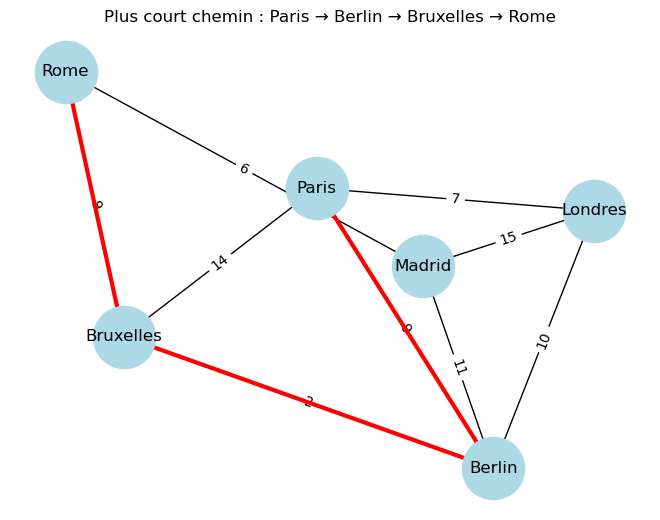

In [1]:
# Installation
import sys
!{sys.executable} -m pip install networkx matplotlib

# Imports
import networkx as nx
import matplotlib.pyplot as plt
from dijkstra_tp import g, shortest, dijkstra

# Exécuter Dijkstra
start = g.get_vertex('Paris')
target = g.get_vertex('Rome')
dijkstra(g, start)

# Création du graphe
G = nx.Graph()

for v in g:
    for w in v.get_connections():
        if (w.get_id(), v.get_id()) not in G.edges():
            G.add_edge(v.get_id(), w.get_id(), weight=v.get_weight(w))

# Position
pos = nx.spring_layout(G)

# Dessin du graphe
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)

# Affichage des poids
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# Plus court chemin
path = shortest(target)
path_edges = list(zip(path, path[1:]))

# Dessiner le chemin en rouge
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

# Titre
plt.title("Plus court chemin : Paris → Berlin → Bruxelles → Rome")

plt.show()